# Color palette overview

Visualizes all colorblind-safe palettes included in the `cb_colors` package.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from cb_colors import palettes

matplotlib.rc_file("../../matplotlibrc_ml")
matplotlib.rcParams.update({"font.size": 7.5, "text.usetex": False})

In [2]:
def draw_swatches(ax, colors, label=None, show_hex=False):
    """Draw a row of color swatches on ax."""
    n = len(colors)
    for i, (name, hex_color) in enumerate(colors.items() if isinstance(colors, dict) else enumerate(colors)):
        rect = mpatches.FancyBboxPatch(
            (i, 0), 0.9, 0.8,
            boxstyle="round,pad=0.05",
            facecolor=hex_color, edgecolor="none"
        )
        ax.add_patch(rect)
        if isinstance(colors, dict) and show_hex:
            ax.text(i + 0.45, -0.18, name, ha="center", va="top",
                    fontsize=5.5, color="#444")
    ax.set_xlim(-0.1, n)
    ax.set_ylim(-0.35, 0.95)
    ax.axis("off")
    if label:
        ax.text(-0.15, 0.4, label, ha="right", va="center",
                fontsize=6.5, fontweight="bold", transform=ax.transData)

In [3]:
def draw_gradient(ax, colors, label=None):
    """Draw a gradient strip from a list of hex colors."""
    n = len(colors)
    for i, hex_color in enumerate(colors):
        rect = mpatches.FancyBboxPatch(
            (i, 0), 0.9, 0.8,
            boxstyle="round,pad=0.02",
            facecolor=hex_color, edgecolor="none"
        )
        ax.add_patch(rect)
    ax.set_xlim(-0.1, n)
    ax.set_ylim(-0.1, 0.95)
    ax.axis("off")
    if label:
        ax.text(-0.15, 0.4, label, ha="right", va="center",
                fontsize=6.5, fontweight="bold", transform=ax.transData)

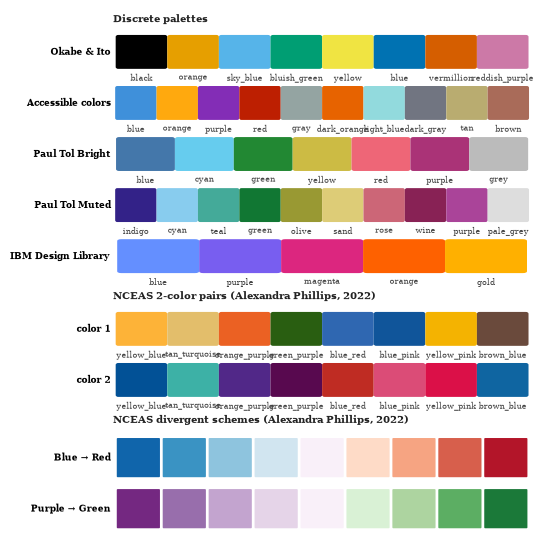

All palettes displayed


In [4]:
# ── Load all palettes ─────────────────────────────────────────────────────────
oi     = palettes.okabe_and_ito()
ac     = palettes.accessible_colors()
ptb    = palettes.paul_tol_bright()
ptm    = palettes.paul_tol_muted()
ibm    = palettes.ibm_design_library()
pairs  = palettes.nceas_two_color_pairs()
btr    = palettes.nceas_blue_to_red()
ptg    = palettes.nceas_purple_to_green()

# 2-color pairs: flatten to dict for swatch drawing
pair_colors_1 = {k: v[0] for k, v in pairs.items()}
pair_colors_2 = {k: v[1] for k, v in pairs.items()}

# ── Layout ────────────────────────────────────────────────────────────────────
# Section heights: each palette row = 1 unit, section label = 0.5 unit
fig, axes = plt.subplots(
    nrows=12, ncols=1,
    figsize=(5.5, 5.5),
    gridspec_kw={"height_ratios": [0.4, 1, 1, 1, 1, 1, 0.4, 1, 1, 0.4, 1, 1]},
)
fig.subplots_adjust(hspace=0.05, left=0.22, right=0.98, top=0.97, bottom=0.02)

def section_header(ax, text):
    ax.text(0, 0.5, text, ha="left", va="center",
            fontsize=7, fontweight="bold", color="#222",
            transform=ax.transAxes)
    ax.axis("off")

section_header(axes[0], "Discrete palettes")
draw_swatches(axes[1],  oi,  label="Okabe & Ito",        show_hex=True)
draw_swatches(axes[2],  ac,  label="Accessible colors",  show_hex=True)
draw_swatches(axes[3],  ptb, label="Paul Tol Bright",    show_hex=True)
draw_swatches(axes[4],  ptm, label="Paul Tol Muted",     show_hex=True)
draw_swatches(axes[5],  ibm, label="IBM Design Library", show_hex=True)

section_header(axes[6], "NCEAS 2-color pairs (Alexandra Phillips, 2022)")
draw_swatches(axes[7],  pair_colors_1, label="color 1", show_hex=True)
draw_swatches(axes[8],  pair_colors_2, label="color 2", show_hex=True)

section_header(axes[9], "NCEAS divergent schemes (Alexandra Phillips, 2022)")
draw_gradient(axes[10], btr, label="Blue → Red")
draw_gradient(axes[11], ptg, label="Purple → Green")

plt.show()
print("All palettes displayed")

In [5]:
# ── Save ──────────────────────────────────────────────────────────────────────
out_path = "../png/color_overview.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {out_path}")

Saved: ../png/color_overview.png
